## Load Packages

In [20]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

In [21]:
def elec(tech=None):
    if not tech is None:
        return f'Secondary Energy|Electricity|{tech}'
    else:
        return 'Secondary Energy|Electricity'

In [22]:
REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')

In [23]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

LAM_ISOS = [
    'ABW', 'ARG', 'ATG', 'BHS', 'BLZ', 'BMU', 'BOL', 'BRA', 'BRB', 'CHL', 'COL',
    'CRI', 'CUB', 'CYM', 'DMA', 'DOM', 'ECU', 'FLK', 'GLP', 'GRD', 'GTM', 'GUF',
    'GUY', 'HND', 'HTI', 'JAM', 'KNA', 'LCA', 'MEX', 'MSR', 'MTQ','NIC', 'PAN', 'PER',
    'PRI', 'PRY', 'SLV', 'SUR', 'TCA', 'TTO', 'URY', 'VCT', 'VEN', 'VGB', 'VIR']

IKEA_ISOS.sort()

## Load data

In [24]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [25]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
    
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [26]:
REMIND_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP1 - Updating global 1.5°C Pathways/"
    "1 - PIK/"
    "Scenario Data/"
    "SUBMITTED_SCENARIOS_August2025/"

)

REMIND_PATH: os.PathLike = BOX_MOUNT_PATH / REMIND_PATH

In [27]:
# INSERT PATHWAY TO INPUT DATA
input_data = pyam.IamDataFrame('../input_data/REMIND_fuel_mix_testing/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv')
# input_data_processed = pyam.IamDataFrame('../input_data/REMIND_fuel_mix_testing/multiple_df/snapshot_all_regions_RAW_REMIND-MAgPIE 3.3-4.8.csv')

pyam.core - INFO: Reading file ../input_data/REMIND_fuel_mix_testing/snapshot_v1/npe_core_scenario_harmonised_AR6_reporting.csv


In [28]:
import pandas as pd

# INSERT PATHWAY TO HISTORICAL DATA HERE
df = pd.read_csv(
    DSCALE_PATH / 'data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv'
)

iamc_cols = ["MODEL", "SCENARIO", "REGION", "VARIABLE", "UNIT"]

df_clean = df.drop_duplicates(
    subset=["MODEL", "SCENARIO", "REGION", "VARIABLE", "UNIT"]
)

hist_data = pyam.IamDataFrame(df_clean)

In [29]:
# PUT PATH TO YOUR DSCALE RESULTS IN HERE
dscale_results = pyam.IamDataFrame('../results/5_Explorer_and_New_Variables/REMIND_fuel_mix_testing/19_02_2026/REMIND 3.4_2022_harmo_step5h_hydrogen.csv')

pyam.core - INFO: Reading file ../results/5_Explorer_and_New_Variables/REMIND_fuel_mix_testing/19_02_2026/REMIND 3.4_2022_harmo_step5h_hydrogen.csv


In [30]:

# Regroup all the rescaled countries within their regions

region_map = {
    'R10AFRICA':'SSA',
    'R10CHINA+':'CHA',
    'R10EUROPE':'EUR',
    'R10LATIN_AM':'LAM',
    'R10MIDDLE_EAST':'MEA',
    'R10REF_ECON':'REF',
    'R10REST_ASIA':'OAS',
    'R10NORTH_AM':'USA',
    'R10PAC_OECD':'JPN',
    'R10INDIA+':'IND',
    'R10ROWO':'ROWO',
    'World':'World'}


def create_macro_df(idf: pyam.IamDataFrame):
    """Converts data at country level to macro-region data"""

    # Dataset preparation
    df_country = idf.timeseries()
    df_country.index.names = ['model', 'scenario', 'country', 'variable', 'unit']
    
    # Label each country based on what region it's part of
    df_country = df_country.pix.semijoin(REMIND_RMAP.index, how="left")

    # Kick out countries which don't have a region mapping               
    df_country=df_country.loc[~isin(region=np.nan)]
    
    # # Groupby regions and sum (much faster than doing in pyam)
    df_country = pyam.IamDataFrame(
        df_country
        .groupby(['model','scenario','variable','unit','region'])
        .sum())
    
    df_region = pyam.IamDataFrame(df_country)
       
    # Drop 2023 data as it is currently missing quite a few countries (and so the regional totals are off)
    df_region.filter(year=2023,keep=False,inplace=True)

    # Rename regions
    df_region = (df_region
                 .rename(region=region_map)
                 .filter(region=['SSA','CHA','NEU','CAZ','EUR','IND','LAM','MEA','USA','JPN','REF','OAS'])
                )

    # Add world data
    for var in df_region.variable:
        df_region.aggregate_region(
            var,
            'World',
            append=True)

    return pyam.IamDataFrame(df_region.timeseries())

In [31]:
dscale_results_agg = create_macro_df(dscale_results)

In [14]:
hist_agg = create_macro_df(hist_data)
hist_agg.filter(year=[2023,2024],keep=False,inplace=True) 
#Drop 2023/2024 data as underlying country data is regionally incomplete and so you get aggregation errors

## Regional consistencies

In [34]:
# ── dscale_results_agg  vs  input_data ───────────────────────────────────────
# Verify that re-aggregating country-level results recovers the original
# regional input data, for every variable present in both.

common_vars    = sorted(set(input_data.filter(variable = ["Emissions*", "Primary*", "Secondary*", "Final*"]).variable) & set(dscale_results_agg.filter(variable = ["Emissions*", "Primary*", "Secondary*", "Final*"]).variable))
common_regions = sorted(set(input_data.filter(region = ["World", "CHA", "JPN", "USA", "IND"], keep=False).region)   & set(dscale_results_agg.filter(region = ["World", "CHA", "JPN", "USA", "IND"], keep=False).region))
common_regions = sorted(set(input_data.region) & set(dscale_results_agg.region))


print(f"Common: {len(common_vars)} variables  ×  {len(common_regions)} regions")
print(f"Regions: {common_regions}\n")

# Extract timeseries; drop model/scenario to align on (region, variable, unit)
ref_ts = input_data.filter(variable=common_vars, region=common_regions, year = [2040,2050,2060,2070,2080]).timeseries()
dsc_ts = dscale_results_agg.filter(variable=common_vars, region=common_regions, year = [2040,2050,2060,2070,2080]).timeseries()

ref_ts.index = ref_ts.index.droplevel(['model', 'scenario'])
dsc_ts.index = dsc_ts.index.droplevel(['model', 'scenario'])

# Align on shared years and index entries
common_years   = sorted(set(ref_ts.columns) & set(dsc_ts.columns))
ref_ts, dsc_ts = ref_ts[common_years].align(dsc_ts[common_years], join='inner')

# Max absolute difference per (region, variable)
max_abs  = (ref_ts - dsc_ts).abs().max(axis=1)
# max_abs  = (ref_ts - dsc_ts).max(axis=1)
summary  = max_abs.reset_index()
summary.columns = ['region', 'variable', 'unit', 'max_abs_diff']
summary  = summary.sort_values('max_abs_diff', ascending=False).reset_index(drop=True)

TOL_AGG  = 0.01  # EJ/yr — adjust as needed
discrepancies = summary[summary['max_abs_diff'] > TOL_AGG]

print(f"Variable × region pairs checked : {len(summary)}")
print(f"Tolerance                        : {TOL_AGG} (units in data, e.g. EJ/yr)")
if discrepancies.empty:
    print("✓  All values match within tolerance")
else:
    print(f"✗  {len(discrepancies)} pairs exceed tolerance\n")
    display(discrepancies.head(20))

Common: 97 variables  ×  2 regions
Regions: ['LAM', 'World']

Variable × region pairs checked : 194
Tolerance                        : 0.01 (units in data, e.g. EJ/yr)
✗  139 pairs exceed tolerance



,region,variable,unit,max_abs_diff
0,World,Emissions|CO2,Mt CO2/yr,6647.945855
1,World,Emissions|CO2|Energy,Mt CO2/yr,6042.556842
2,World,Emissions|CO2|Industrial Processes,Mt CO2/yr,2548.939270
3,World,Emissions|CO2|Energy|Demand|Industry,Mt CO2/yr,2084.031911
4,World,Primary Energy,EJ/yr,773.547694
5,World,Emissions|CO2|Energy|Demand|Residential and Co...,Mt CO2/yr,744.280093
6,World,Secondary Energy|Electricity,EJ/yr,616.374676
7,LAM,Emissions|CO2,Mt CO2/yr,560.429802
8,World,Final Energy,EJ/yr,507.478905
9,World,Primary Energy|Solar,EJ/yr,446.501579


In [35]:
discrepancies.loc[discrepancies["variable"] == "Final Energy"]

,region,variable,unit,max_abs_diff
8,World,Final Energy,EJ/yr,507.478905
83,LAM,Final Energy,EJ/yr,1.800171


pyam.core - WARNING: Filtered IamDataFrame is empty!


<Axes: xlabel='Year', ylabel='Value'>

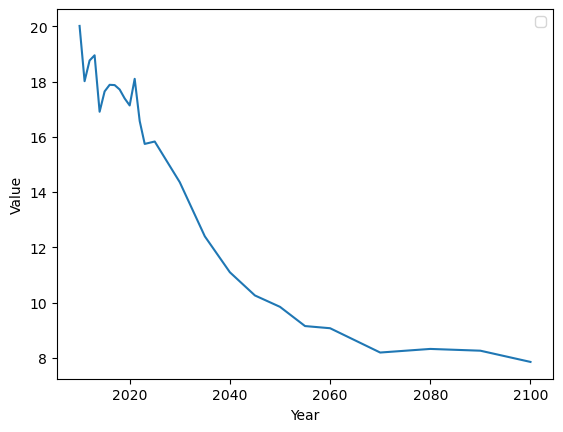

In [36]:
variable = "Final Energy|Residential and Commercial"
input_data.filter(region="EUR", variable = variable).plot()
dscale_results_agg.filter(region="EUR", variable = variable).plot(ax=plt.gca())

## Final Energy consistencies

In [37]:
_ts   = dscale_results.filter(region = ["CHN", "IND", "USA", "JPN"], keep=False).timeseries()
_vars = set(_ts.index.get_level_values('variable'))
TOL   = 0.01   # EJ/yr — absolute tolerance for all FE checks

In [38]:
# ── Pre-load country-level timeseries once (used by all checks below) ────────
# _ts   = dscale_results.filter(region = ["CHN", "IND", "USA", "JPN"], keep=False).timeseries()
_ts   = dscale_results.filter(region = ["CHN", "IND", "USA", "JPN"], keep=False).timeseries()
_vars = set(_ts.index.get_level_values('variable'))
TOL   = 0.01   # EJ/yr — absolute tolerance for all FE checks


def check_sum(agg_var, comp_vars):
    """Sum comp_vars and compare to agg_var across all countries.
    Returns a DataFrame of absolute differences: rows = countries, cols = years.
    Prints a warning for any comp_vars missing from the data.
    """
    found   = [v for v in comp_vars if v in _vars]
    missing = [v for v in comp_vars if v not in _vars]
    if missing:
        print(f"    ⚠ not in data: {missing}")
    if agg_var not in _vars or not found:
        return pd.DataFrame()

    agg  = _ts.loc[_ts.index.isin([agg_var], level='variable')].droplevel('variable')
    ssum = (_ts.loc[_ts.index.isin(found, level='variable')]
               .groupby(level=['model', 'scenario', 'region', 'unit']).sum())

    agg, ssum = agg.align(ssum, join='inner')
    return (agg - ssum).abs()                          # full country × year grid


def summarise(checks, title):
    """Run check_sum for every {agg_var: [comp_vars]} entry; display a summary table."""
    rows = []
    for agg_var, comp_vars in checks.items():
        diffs = check_sum(agg_var, comp_vars)          # DataFrame: countries × years
        if diffs.empty:
            rows.append(dict(check=agg_var, countries=0, n_fail_countries=0,
                             n_fail_years=0, max_diff=np.nan, worst="N/A"))
            continue

        max_per_country = diffs.max(axis=1)            # worst year per country
        n_fail_countries = int((max_per_country > TOL).sum())
        n_fail_years     = int((diffs > TOL).sum().sum())   # total failing country×year cells

        rows.append(dict(
            check            = agg_var,
            countries        = len(diffs),
            n_fail_countries = n_fail_countries,
            n_fail_years     = n_fail_years,
            max_diff         = round(float(max_per_country.max()), 6),
            worst            = max_per_country.idxmax()[2] if n_fail_countries > 0 else "–",
        ))

    out = pd.DataFrame(rows)
    out.insert(0, '', out['n_fail_countries'].map(lambda x: '✓' if x == 0 else '✗'))
    print(f"\n{'─'*70}\n  {title}\n{'─'*70}")
    # display(out)
    return out




### Fuel are consistent with their carriers within each sector

In [39]:
# ── Fuel → Carrier definitions (only carriers that have sub-fuel splits) ─────
FUEL_TO_CARRIER = {
    # Industry
    "Final Energy|Industry|Gases" : ["Final Energy|Industry|Gases|Biomass",
                                     "Final Energy|Industry|Gases|Natural Gas",
                                     "Final Energy|Industry|Gases|Hydrogen synfuel",
                                     "Final Energy|Industry|Gases|Electricity"],
    "Final Energy|Industry|Liquids": ["Final Energy|Industry|Liquids|Biomass",
                                      "Final Energy|Industry|Liquids|Oil",
                                      "Final Energy|Industry|Liquids|Electricity"],
    "Final Energy|Industry|Solids" : ["Final Energy|Industry|Solids|Biomass",
                                      "Final Energy|Industry|Solids|Coal"],
    # Residential & Commercial
    "Final Energy|Residential and Commercial|Gases" : ["Final Energy|Residential and Commercial|Gases|Biomass",
                                                        "Final Energy|Residential and Commercial|Gases|Natural Gas",
                                                        "Final Energy|Residential and Commercial|Gases|Electricity"],
    "Final Energy|Residential and Commercial|Liquids": ["Final Energy|Residential and Commercial|Liquids|Biomass",
                                                         "Final Energy|Residential and Commercial|Liquids|Oil",
                                                         "Final Energy|Residential and Commercial|Liquids|Electricity"],
    "Final Energy|Residential and Commercial|Solids" : ["Final Energy|Residential and Commercial|Solids|Biomass",
                                                         "Final Energy|Residential and Commercial|Solids|Coal"],
    # Transportation
    "Final Energy|Transportation|Gases" : ["Final Energy|Transportation|Gases|Biomass",
                                            "Final Energy|Transportation|Gases|Natural Gas",
                                            "Final Energy|Transportation|Gases|Electricity"],
    "Final Energy|Transportation|Liquids": ["Final Energy|Transportation|Liquids|Biomass",
                                             "Final Energy|Transportation|Liquids|Oil",
                                             "Final Energy|Transportation|Liquids|Coal",
                                             "Final Energy|Transportation|Liquids|Electricity"],
}

summarise(FUEL_TO_CARRIER, "Fuels  →  Carrier  (per sector)")

    ⚠ not in data: ['Final Energy|Industry|Gases|Hydrogen synfuel']

──────────────────────────────────────────────────────────────────────
  Fuels  →  Carrier  (per sector)
──────────────────────────────────────────────────────────────────────


,,check,countries,n_fail_countries,n_fail_years,max_diff,worst
0,✗,Final Energy|Industry|Gases,35,9,15,0.158021,PRI
1,✗,Final Energy|Industry|Liquids,35,9,22,0.192780,PRI
2,✗,Final Energy|Industry|Solids,35,8,42,0.199000,PRI
3,✗,Final Energy|Residential and Commercial|Gases,35,5,9,0.084569,ARG
4,✗,Final Energy|Residential and Commercial|Liquids,35,9,16,0.136833,PRI
5,✗,Final Energy|Residential and Commercial|Solids,35,7,37,0.185600,PRI
6,✗,Final Energy|Transportation|Gases,35,4,8,0.047293,PRI
7,✗,Final Energy|Transportation|Liquids,35,10,23,0.191074,PRI


### Carriers are consistent with the total sector 

In [40]:
# ── Carriers  →  Sector total ─────────────────────────────────────────────────
# Note: REMIND uses "Statistical Difference" adjustment variables in some
# sectors.  If a sector has one, expect a small residual here.

CARRIERS_IN_SECTOR = {
    "Final Energy|Industry": [
        "Final Energy|Industry|Electricity",
        "Final Energy|Industry|Gases",
        "Final Energy|Industry|Heat",
        "Final Energy|Industry|Hydrogen",
        "Final Energy|Industry|Liquids",
        "Final Energy|Industry|Solids",
    ],
    "Final Energy|Residential and Commercial": [
        "Final Energy|Residential and Commercial|Electricity",
        "Final Energy|Residential and Commercial|Gases",
        "Final Energy|Residential and Commercial|Heat",
        "Final Energy|Residential and Commercial|Hydrogen",
        "Final Energy|Residential and Commercial|Liquids",
        "Final Energy|Residential and Commercial|Solids",
    ],
    "Final Energy|Transportation": [
        "Final Energy|Transportation|Electricity",
        "Final Energy|Transportation|Gases",
        "Final Energy|Transportation|Hydrogen",
        "Final Energy|Transportation|Liquids",
        # no Heat / Solids in Transportation
    ],
    "Final Energy|Other Sector": [
        "Final Energy|Other Sector|Electricity",
        "Final Energy|Other Sector|Gases",
        "Final Energy|Other Sector|Heat",
        "Final Energy|Other Sector|Hydrogen",
        "Final Energy|Other Sector|Liquids",
        # no Solids in Other Sector
    ],
}

summarise(CARRIERS_IN_SECTOR, "Carriers  →  Sector total")

    ⚠ not in data: ['Final Energy|Other Sector|Electricity', 'Final Energy|Other Sector|Gases', 'Final Energy|Other Sector|Heat', 'Final Energy|Other Sector|Hydrogen', 'Final Energy|Other Sector|Liquids']

──────────────────────────────────────────────────────────────────────
  Carriers  →  Sector total
──────────────────────────────────────────────────────────────────────


,,check,countries,n_fail_countries,n_fail_years,max_diff,worst
0,✗,Final Energy|Industry,35,19,175,0.259225,BRA
1,✗,Final Energy|Residential and Commercial,35,17,118,0.296638,MEX
2,✗,Final Energy|Transportation,35,18,141,0.341820,BRA
3,✓,Final Energy|Other Sector,0,0,0,NaN,N/A


<Axes: title={'center': 'model: REMIND 3.4 - scenario: NPE-core - region: MEX - variable: Final Energy|Residential and Commercial'}, xlabel='Year', ylabel='EJ/yr'>

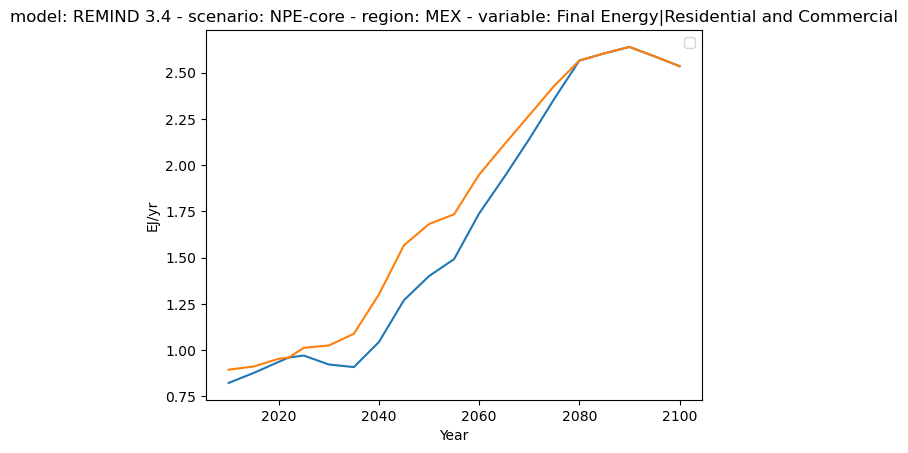

In [44]:
dscale_results.aggregate("Final Energy|Residential and Commercial", [
        "Final Energy|Residential and Commercial|Electricity",
        "Final Energy|Residential and Commercial|Gases",
        "Final Energy|Residential and Commercial|Heat",
        "Final Energy|Residential and Commercial|Hydrogen",
        "Final Energy|Residential and Commercial|Liquids",
        "Final Energy|Residential and Commercial|Solids",
    ],).filter(region = "MEX").plot()

dscale_results.filter(variable = "Final Energy|Residential and Commercial", region = "MEX").plot(ax=plt.gca())

<Axes: title={'center': 'model: REMIND 3.4 - scenario: NPE-core - region: BRA - variable: Final Energy|Industry'}, xlabel='Year', ylabel='EJ/yr'>

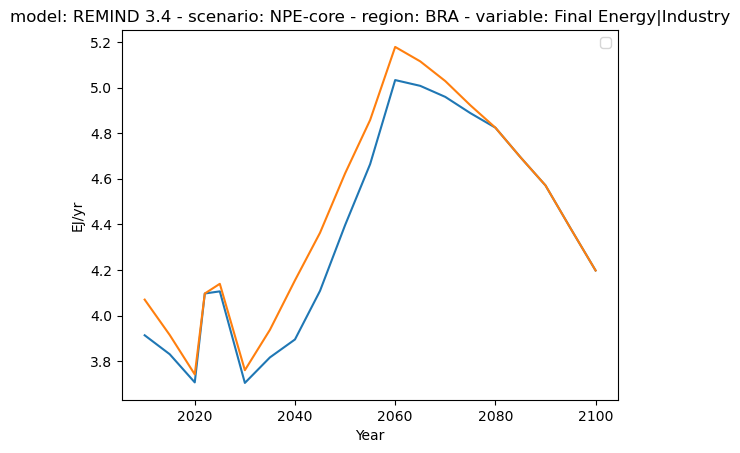

In [45]:
dscale_results.aggregate("Final Energy|Industry", [
        "Final Energy|Industry|Electricity",
        "Final Energy|Industry|Gases",
        "Final Energy|Industry|Heat",
        "Final Energy|Industry|Hydrogen",
        "Final Energy|Industry|Liquids",
        "Final Energy|Industry|Solids",
    ],).filter(region = "BRA").plot()

dscale_results.filter(variable = "Final Energy|Industry", region = "BRA").plot(ax=plt.gca())

### Carriers in sector consistent with FE|Carriers

In [76]:
# ── Sum of sector-level carriers  →  top-level FE|Carrier ────────────────────
# e.g. FE|Electricity = Industry|Elec + R&C|Elec + Transport|Elec + Other|Elec

CARRIER_ACROSS_SECTORS = {
    "Final Energy|Electricity": [
        "Final Energy|Industry|Electricity",
        "Final Energy|Residential and Commercial|Electricity",
        "Final Energy|Transportation|Electricity",
        "Final Energy|Other Sector|Electricity",
    ],
    "Final Energy|Gases": [
        "Final Energy|Industry|Gases",
        "Final Energy|Residential and Commercial|Gases",
        "Final Energy|Transportation|Gases",
        "Final Energy|Other Sector|Gases",
    ],
    "Final Energy|Heat": [
        "Final Energy|Industry|Heat",
        "Final Energy|Residential and Commercial|Heat",
        "Final Energy|Other Sector|Heat",
        # Transportation has no Heat
    ],
    "Final Energy|Hydrogen": [
        "Final Energy|Industry|Hydrogen",
        "Final Energy|Residential and Commercial|Hydrogen",
        "Final Energy|Transportation|Hydrogen",
        "Final Energy|Other Sector|Hydrogen",
    ],
    "Final Energy|Liquids": [
        "Final Energy|Industry|Liquids",
        "Final Energy|Residential and Commercial|Liquids",
        "Final Energy|Transportation|Liquids",
        "Final Energy|Other Sector|Liquids",
    ],
    "Final Energy|Solids": [
        "Final Energy|Industry|Solids",
        "Final Energy|Residential and Commercial|Solids",
        # Transportation and Other Sector have no Solids
    ],
}

summarise(CARRIER_ACROSS_SECTORS, "Sum(Sector|Carrier) across sectors  →  FE|Carrier")

    ⚠ not in data: ['Final Energy|Other Sector|Electricity']
    ⚠ not in data: ['Final Energy|Other Sector|Gases']
    ⚠ not in data: ['Final Energy|Other Sector|Heat']
    ⚠ not in data: ['Final Energy|Other Sector|Hydrogen']
    ⚠ not in data: ['Final Energy|Other Sector|Liquids']

──────────────────────────────────────────────────────────────────────
  Sum(Sector|Carrier) across sectors  →  FE|Carrier
──────────────────────────────────────────────────────────────────────


,,check,countries,n_fail_countries,n_fail_years,max_diff,worst
0,✗,Final Energy|Electricity,28,21,178,0.183400,FRA
1,✗,Final Energy|Gases,28,19,101,0.237308,NLD
2,✓,Final Energy|Heat,28,0,0,0.009500,–
3,✓,Final Energy|Hydrogen,0,0,0,NaN,N/A
4,✗,Final Energy|Liquids,28,24,179,0.374345,FRA
5,✗,Final Energy|Solids,28,8,43,0.121700,DEU


### Sum(Sector) == Final Energy

In [77]:
# ── Sum of sectors  →  Final Energy ───────────────────────────────────────────

SECTORS = {
    "Final Energy": [
        "Final Energy|Industry",
        "Final Energy|Residential and Commercial",
        "Final Energy|Transportation",
        "Final Energy|Other Sector",
    ],
}

summarise(SECTORS, "Sum(Sectors)  →  Final Energy")

    ⚠ not in data: ['Final Energy|Other Sector']

──────────────────────────────────────────────────────────────────────
  Sum(Sectors)  →  Final Energy
──────────────────────────────────────────────────────────────────────


,,check,countries,n_fail_countries,n_fail_years,max_diff,worst
0,✗,Final Energy,28,23,297,0.351,FRA


<Axes: title={'center': 'model: REMIND 3.4 - scenario: NPE-core - region: FRA - variable: Final Energy'}, xlabel='Year', ylabel='EJ/yr'>

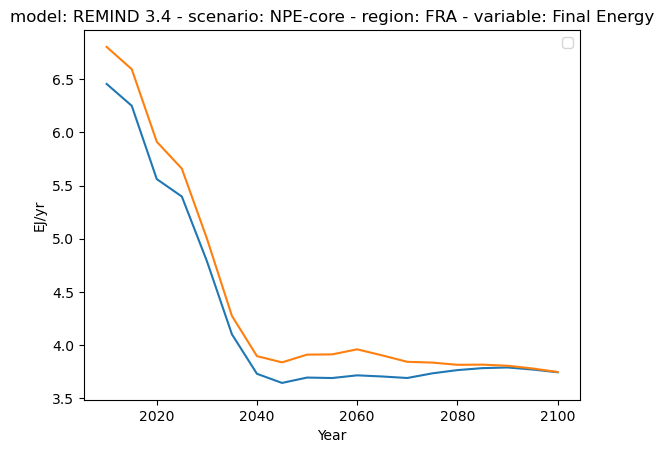

In [78]:
dscale_results.aggregate("Final Energy",[
        "Final Energy|Industry",
        "Final Energy|Residential and Commercial",
        "Final Energy|Transportation",
        "Final Energy|Other Sector",
    ],).filter(region = "FRA").plot()

dscale_results.filter(variable = "Final Energy", region = "FRA").plot(ax=plt.gca())

### Sum(Carriers) == Final Energy

In [79]:
# ── Sum of carriers  →  Final Energy ──────────────────────────────────────────

CARRIERS = {
    "Final Energy": [
        "Final Energy|Electricity",
        "Final Energy|Gases",
        "Final Energy|Heat",
        "Final Energy|Hydrogen",
        "Final Energy|Liquids",
        "Final Energy|Solids",
    ],
}

summarise(CARRIERS, "Sum(Carriers)  →  Final Energy")

    ⚠ not in data: ['Final Energy|Hydrogen']

──────────────────────────────────────────────────────────────────────
  Sum(Carriers)  →  Final Energy
──────────────────────────────────────────────────────────────────────


,,check,countries,n_fail_countries,n_fail_years,max_diff,worst
0,✗,Final Energy,28,22,288,0.7411,DEU


# Final Energy|Electricity ≤ Secondary Energy|Electricity

In [84]:
# ── FE|Electricity must not exceed SE|Electricity ─────────────────────────────
# Electricity consumption (FE) can never be larger than production (SE).

fe_var = "Final Energy|Electricity"
se_var = "Secondary Energy|Electricity"

fe_ts = _ts.loc[_ts.index.isin([fe_var], level='variable')].droplevel('variable')
se_ts = _ts.loc[_ts.index.isin([se_var], level='variable')].droplevel('variable')

fe_ts, se_ts = fe_ts.align(se_ts, join='inner')

# Excess = FE − SE;  only positive values are violations
excess = fe_ts - se_ts
violations = excess > TOL                                  # boolean mask

n_violations = int(violations.sum().sum())                 # total country × year cells
n_countries  = int(violations.any(axis=1).sum())           # countries with ≥1 bad year

if n_violations == 0:
    print("✓  FE|Electricity ≤ SE|Electricity everywhere")
else:
    print(f"✗  {n_violations} country × year violations  ({n_countries} countries)\n")
    print(f"   Max excess : {excess.max().max():.6f}\n")

    # Worst offenders: max excess per country, descending
    worst = (excess.max(axis=1)
             .pipe(lambda s: s[s > TOL])
             .sort_values(ascending=False)
             .rename('max_excess'))
    worst.index = worst.index.droplevel(['model', 'scenario', 'unit'])
    display(worst.reset_index().head(20))

✗  38 country × year violations  (11 countries)

   Max excess : 0.170100



,region,max_excess
0,POL,0.1701
1,ITA,0.0624
2,BEL,0.0510
3,BGR,0.0460
4,FIN,0.0379
5,LUX,0.0353
6,ROU,0.0303
7,LTU,0.0224
8,HUN,0.0220
9,PRT,0.0157


<Axes: title={'center': 'model: REMIND 3.4 - scenario: NPE-core - region: POL'}, xlabel='Year', ylabel='EJ/yr'>

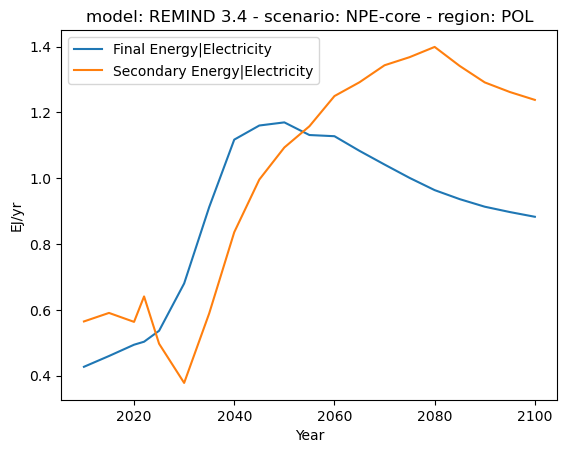

In [85]:
country = "POL"
dscale_results.filter(variable = ["Final Energy|Electricity", "Secondary Energy|Electricity"], region = country).plot()

# Primary Energy ≥ Final Energy (fuel supply)

Each fossil fuel consumed in final energy must be covered by primary energy supply.
PE includes net trade (imports), so PE ≥ FE should hold at the **regional** level.

At the **country** level, however, REMIND does not track intra-regional fuel trade: PE and FE are downscaled with different geographic shares, so oil- and gas-importing countries routinely show FE > PE. This is a structural feature of the downscaling, not a bug.

* **Coal**: no violations expected (coal trade within REMIND regions is small).
* **Oil / Gas**: country-level violations are expected and should not be "fixed" by clipping — doing so would artificially cut consumption in importing countries.

In [81]:
# ── PE ≥ FE fuel-level checks ─────────────────────────────────────────────────
# Positive excess  =  more of that fuel consumed in FE than supplied in PE.
# For Oil and Gas this is expected for intra-regional importing countries.

PE_GE_FE = {
    "Coal":        ("Primary Energy|Coal",  ["Final Energy|Solids|Coal"]),
    "Oil":         ("Primary Energy|Oil",   ["Final Energy|Industry|Liquids|Oil",
                                             "Final Energy|Residential and Commercial|Liquids|Oil",
                                             "Final Energy|Transportation|Liquids|Oil"]),
    "Natural Gas": ("Primary Energy|Gas",   ["Final Energy|Industry|Gases|Natural Gas",
                                             "Final Energy|Residential and Commercial|Gases|Natural Gas",
                                             "Final Energy|Transportation|Gases|Natural Gas"]),
}

rows = []
for fuel, (pe_var, fe_vars) in PE_GE_FE.items():
    found_fe = [v for v in fe_vars if v in _vars]
    if pe_var not in _vars or not found_fe:
        continue

    pe_ts = _ts.loc[_ts.index.isin([pe_var], level='variable')].droplevel('variable')
    fe_ts = (_ts.loc[_ts.index.isin(found_fe, level='variable')]
                .groupby(level=['model', 'scenario', 'region', 'unit']).sum())
    pe_ts, fe_ts = pe_ts.align(fe_ts, join='inner')

    excess           = fe_ts - pe_ts                       # >0  →  FE > PE
    max_per_country  = excess.max(axis=1)
    n_fail_countries = int((max_per_country > TOL).sum())
    n_fail_years     = int((excess > TOL).sum().sum())

    rows.append(dict(
        fuel             = fuel,
        PE               = pe_var,
        n_fail_countries = n_fail_countries,
        n_fail_years     = n_fail_years,
        max_excess       = round(float(max_per_country.max()), 4),
        worst            = max_per_country.idxmax()[2] if n_fail_countries > 0 else "–",
    ))

out = pd.DataFrame(rows)
out.insert(0, '', out['n_fail_countries'].map(lambda x: '✓' if x == 0 else '✗'))
print(f"\n{'─'*70}\n  Primary Energy ≥ Final Energy (fuel supply)\n{'─'*70}")
display(out)


──────────────────────────────────────────────────────────────────────
  Primary Energy ≥ Final Energy (fuel supply)
──────────────────────────────────────────────────────────────────────


,,fuel,PE,n_fail_countries,n_fail_years,max_excess,worst
0,✗,Oil,Primary Energy|Oil,2,13,0.0407,EST
1,✗,Natural Gas,Primary Energy|Gas,6,9,0.1231,DEU


Why no code fix was applied for oil/gas:

The oil and gas violations are not a bug — they're an expected consequence of the downscaling methodology. I verified this by checking the REMIND regional input: at the regional level, PE|Oil > FE|Oil everywhere (the energy balance is correct). The country-level violations exist because REMIND doesn't track intra-regional fuel trade. When PE and FE are distributed to countries using different shares (PE via production shares, FE via consumption shares), importing countries end up with FE > PE. Clipping would be incorrect — it would artificially cut consumption in those countries. Coal has no violations because intra-regional coal trade is negligible compared to oil/gas.

The violations pre-exist before step5e (92 countries in Step5d for oil), so this isn't a harmonization artifact either — it's structural to the downscaling approach.